# Clase 7: Etapas finales de la Evolución


## Objetivos
1. El Paradigma Roto: Múltiples Poblaciones en Cúmulos Globulares.
2. Astrometría de Precisión en la Era de Gaia.
3. Detección de Corrientes Estelares y Colas de Marea.



## 1. El Paradigma Roto: Múltiples Poblaciones en Cúmulos Globulares

Durante décadas, los cúmulos globulares (GCs) se consideraron Poblaciones Estelares Simples (SSP): aglomeraciones de estrellas coetáneas con idéntica metalicidad y abundancia química inicial. Hoy sabemos que casi todos los GCs masivos albergan **Múltiples Poblaciones (MPs)**. Las estrellas de segunda generación (2G) presentan anomalías químicas (anti-correlaciones Na-O, C-N) y variaciones en la abundancia de Helio ($Y$) que alteran profundamente la estructura estelar y su evolución.

### 1.1 La Ley de Kramers y la Opacidad
La opacidad interior de una estrella de secuencia principal de baja masa está dominada por transiciones ligadas-libres (bound-free) y libres-libres (free-free). La dependencia fundamental de esta opacidad ($\kappa$) se describe mediante la **Ley de Kramers**:

$$\kappa \propto \rho T^{-3.5}$$

Al introducir la dependencia química, la opacidad total se aproxima como:

$$\kappa \approx \kappa_0 Z (1+X) \rho T^{-3.5}$$

Un aumento en la fracción de masa de Helio ($Y$) implica una reducción proporcional en Hidrógeno ($X$). Esto disminuye la opacidad general de la estrella. Al haber menos "fricción" radiativa, la energía escapa más fácilmente, lo que requiere un reajuste en la estructura hidrostática.

### 1.2 Relación Masa-Luminosidad y Composición Química
Para entender el impacto observacional, partimos de las relaciones de homología estelar. La ecuación de transporte radiativo establece que la luminosidad $L$ escala como:

$$L \propto \frac{R^4 T^4}{\kappa M}$$

Sustituyendo la opacidad de Kramers ($\kappa \propto \frac{M}{R^3} T^{-3.5}$), obtenemos:

$$L \propto \frac{R^7 T^{7.5}}{M^2}$$

Utilizando la relación del teorema del virial para el equilibrio hidrostático ($T \propto \frac{\mu M}{R}$), donde $\mu$ es el peso molecular medio, la luminosidad se reescribe eliminando la temperatura:

$$L \propto \mu^{7.5} M^{5.5} R^{-0.5}$$

El peso molecular medio depende fuertemente del Helio:

$$\mu = \frac{4}{2X + \frac{3}{4}Y + \frac{1}{2}Z}$$

Una población 2G con mayor Helio ($\Delta Y > 0$) tiene un $\mu$ sustancialmente mayor, lo que incrementa su luminosidad dramáticamente para una misma masa.

### 1.3 Cronometría Estelar y la Abundancia de Helio
El tiempo de vida de una estrella en la secuencia principal ($t_{\text{MS}}$) es proporcional a la masa dividida por la luminosidad:

$$t_{\text{MS}} \propto \frac{M}{L}$$

Sustituyendo nuestra relación de luminosidad y considerando que la edad del cúmulo se mide en el *Turn-Off* (MSTO), la variación relativa de la edad estimada en función del Helio se aproxima derivando las ecuaciones de homología:

$$\frac{\Delta t_{\text{TO}}}{t_{\text{TO}}} \approx -1.3 \Delta Y$$

**Conclusión Física:** Si en un cúmulo globular existe una sub-población enriquecida en Helio ($\Delta Y \approx 0.05$), esta parecerá un 6.5% más joven en el Diagrama Color-Magnitud (CMD), creando un desdoblamiento del MSTO que rompe el paradigma de coetaneidad estricta.

### 1.4 Evidencia Observacional (Script Gaia DR3: Omega Centauri)
Aunque el HST es el estándar de oro, en cúmulos con variaciones extremas de metalicidad y Helio como **Omega Centauri (NGC 5139)**, el desdoblamiento puede resolverse con fotometría de banda ancha de Gaia. El siguiente script extrae miembros cinemáticos y muestra la dramática bifurcación de su Rama de Gigantes Rojas (RGB)[cite: 5].

Extrayendo fotometría y cinemática de Omega Centauri...


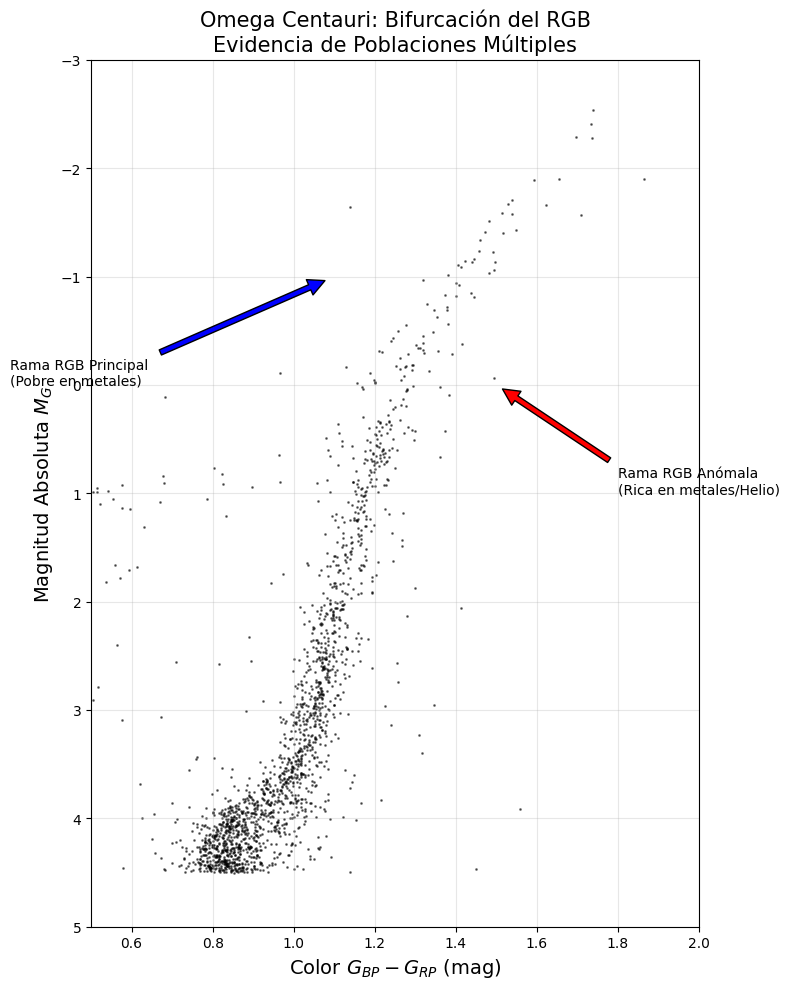

In [3]:
!pip install astroquery
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia

def plot_omega_cen_multiple_populations():
    print("Extrayendo fotometría y cinemática de Omega Centauri...")
    # Coordenadas de Omega Cen: RA = 201.697, Dec = -47.479
    # pmRA ~ -3.19, pmDec ~ -6.74
    query = """
    SELECT ra, dec, parallax, pmra, pmdec, phot_g_mean_mag, bp_rp
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 201.697, -47.479, 0.25)) = 1
      AND pmra BETWEEN -4.5 AND -2.0
      AND pmdec BETWEEN -8.0 AND -5.5
      AND parallax < 0.5
      AND phot_g_mean_mag < 18.0
    """
    job = Gaia.launch_job(query)
    df = job.get_results().to_pandas().dropna()

    # Módulo de distancia aproximado (d ~ 5.2 kpc -> DM ~ 13.5)
    df['M_G'] = df['phot_g_mean_mag'] - 13.5

    plt.figure(figsize=(8, 10))
    plt.scatter(df['bp_rp'], df['M_G'], s=1, color='black', alpha=0.5)
    plt.gca().invert_yaxis()
    plt.xlabel('Color $G_{BP} - G_{RP}$ (mag)', fontsize=14)
    plt.ylabel('Magnitud Absoluta $M_G$', fontsize=14)
    plt.title('Omega Centauri: Bifurcación del RGB\nEvidencia de Poblaciones Múltiples', fontsize=15)

    # Anotaciones para guiar al estudiante
    plt.annotate('Rama RGB Anómala\n(Rica en metales/Helio)', xy=(1.5, 0), xytext=(1.8, 1),
                 arrowprops=dict(facecolor='red', shrink=0.05))
    plt.annotate('Rama RGB Principal\n(Pobre en metales)', xy=(1.1, -1), xytext=(0.3, 0),
                 arrowprops=dict(facecolor='blue', shrink=0.05))

    plt.grid(alpha=0.3)
    plt.xlim(0.5, 2.0)
    plt.ylim(5.0, -3.0)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_omega_cen_multiple_populations()

### 1.4 Mapas Cromosómicos (Chromosome Maps) con HST
Para desentrañar las MPs, la fotometría óptica tradicional no es suficiente. El Telescopio Espacial Hubble (HST) utiliza los filtros ultravioletas WFC3/UVIS para construir "Mapas Cromosómicos".
Esto se logra combinando índices sensibles a distintas moléculas atmosféricas:
* **Eje X ($C_{F275W, F336W, F438W}$):** Se define como $(m_{F275W} - m_{F336W}) - (m_{F336W} - m_{F438W})$. Este índice mide la amplitud del salto de Balmer y las bandas de absorción molecular de NH y CN. Separa estrellas ricas en Nitrógeno (2G) de las normales (1G).
* **Eje Y ($\Delta_{F275W, F814W}$):** Mide la base de temperatura (color basal). Estrellas ricas en Helio son más calientes, por lo que este eje separa a las poblaciones según su fracción $Y$.

### Simulación Teórica de Múltiples Poblaciones (Pseudo-CMD)


<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1124/2239389135.py:20: SyntaxWarning: invalid escape sequence '\D'
  plt.scatter(color_2g, mag_2g, s=5, c='red', alpha=0.6, label='2G (Enriquecida: Pobre en O, Rico en Na, $\Delta Y > 0$)')


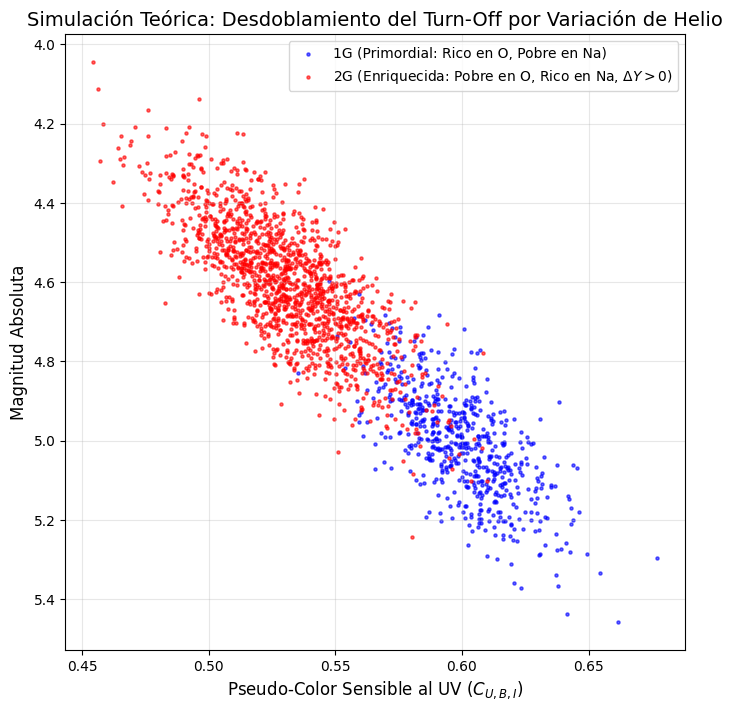

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Simulación de un cúmulo con dos poblaciones estelares (1G y 2G)
np.random.seed(42)
N_estrellas = 2000

# Población 1G (Composición primordial: Helio normal, Oxígeno alto)
N_1g = int(N_estrellas * 0.3)
color_1g = np.random.normal(0.6, 0.02, N_1g)
mag_1g = 5.0 * color_1g + np.random.normal(2.0, 0.1, N_1g)

# Población 2G (Composición alterada: Helio enriquecido, Oxígeno bajo -> más azul en UV)
N_2g = N_estrellas - N_1g
color_2g = np.random.normal(0.53, 0.025, N_2g) # Desplazamiento hacia el azul por del(Y)
mag_2g = 5.0 * color_2g + np.random.normal(1.95, 0.1, N_2g)

plt.figure(figsize=(8, 8))
plt.scatter(color_1g, mag_1g, s=5, c='blue', alpha=0.6, label='1G (Primordial: Rico en O, Pobre en Na)')
plt.scatter(color_2g, mag_2g, s=5, c='red', alpha=0.6, label='2G (Enriquecida: Pobre en O, Rico en Na, $\Delta Y > 0$)')
plt.gca().invert_yaxis()
plt.title("Simulación Teórica: Desdoblamiento del Turn-Off por Variación de Helio", fontsize=14)
plt.xlabel("Pseudo-Color Sensible al UV ($C_{U,B,I}$)", fontsize=12)
plt.ylabel("Magnitud Absoluta", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2. Astrometría de Precisión en la Era de Gaia

La misión Gaia mide los cinco parámetros astrométricos básicos ($\alpha, \delta, \varpi, \mu_\alpha^*, \mu_\delta$) con precisiones de micro-segundos de arco ($\mu$as). Sin embargo, explotar estos datos exige un tratamiento estadístico riguroso de la matriz de covarianza y la propagación de errores.

### Demostración Matemática: Velocidad Tangencial y Propagación de Errores

La velocidad tangencial $v_T$ (en km/s) se deriva del movimiento propio total $\mu = \sqrt{(\mu_\alpha^*)^2 + \mu_\delta^2}$ (en mas/año) y el paralaje $\varpi$ (en mas):

$$v_T = A \frac{\mu}{\varpi}$$

Donde $A = 4.74047$ es la constante de conversión astronómica (1 UA / 1 año en km/s).

Para calcular la incertidumbre $\sigma_{v_T}$, aplicamos la propagación de errores asumiendo correlaciones ($C_{\mu, \varpi}$):

$$\sigma_{v_T}^2 = \left( \frac{\partial v_T}{\partial \mu} \right)^2 \sigma_\mu^2 + \left( \frac{\partial v_T}{\partial \varpi} \right)^2 \sigma_\varpi^2 + 2 \left( \frac{\partial v_T}{\partial \mu} \right) \left( \frac{\partial v_T}{\partial \varpi} \right) C_{\mu, \varpi}$$

Calculando las derivadas parciales:

$$\frac{\partial v_T}{\partial \mu} = \frac{A}{\varpi}, \quad \frac{\partial v_T}{\partial \varpi} = -A \frac{\mu}{\varpi^2}$$

Sustituyendo:

$$\left( \frac{\sigma_{v_T}}{v_T} \right)^2 = \left( \frac{\sigma_\mu}{\mu} \right)^2 + \left( \frac{\sigma_\varpi}{\varpi} \right)^2 - 2 \frac{C_{\mu, \varpi}}{\mu \varpi}$$

> **RUWE y el Sesgo de Lutz-Kelker**
> 1. **RUWE (Renormalised Unit Weight Error):** Un valor RUWE $> 1.4$ en Gaia indica que el modelo astrométrico de fuente única falla. Suele revelar sistemas binarios no resueltos o ruido instrumental.
> 2. **Sesgo de Lutz-Kelker:** Invertir el paralaje ($d = 1/\varpi$) genera estimaciones de distancia sobreestimadas porque el volumen del espacio crece con $d^2$, haciendo que siempre haya más estrellas a distancias mayores cuyos errores las "empujen" estadísticamente hacia paralajes medidos más grandes.

### Extracción Astrométrica y Calidad en Gaia
La astrometría moderna depende de minimizar los sesgos en la matriz de covarianza paramétrica. En la figura previamente generada de los datos del halo galáctico (Histograma y Diagrama de Vector de Puntos - VPD), observamos dos herramientas críticas:

- **VPD (Vector Point Diagram)**: Es un gráfico de $\mu_{α*}$ vs $\mu_\delta$. En este espacio paramétrico, un cúmulo estelar ligado gravitacionalmente aparecerá como un grupo compacto y denso (overdensity), ya que todas sus estrellas comparten un movimiento sistémico idéntico en el cielo, con una pequeña dispersión correspondiente a su velocidad virial interna (∼5−10 km/s). Por el contrario, las estrellas del halo galáctico aparecen dispersas isotrópicamente en el VPD, ya que no están cinemáticamente asociadas.

- **Distribución de Velocidades Tangenciales**: El histograma muestra la cinemática caliente del halo\. Al aislar un cúmulo, el histograma de velocidad colapsa en un pico estrecho (función delta suavizada por errores observacionales). Esta separación en el espacio de fase 5D ($α, \delta, \varpi, \mu_{α*}, \mu_\delta$) es el paso fundamental antes de cualquier análisis de diagramas color-magnitud.


<>:38: SyntaxWarning: invalid escape sequence '\c'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\c'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1124/905732445.py:38: SyntaxWarning: invalid escape sequence '\c'
  ax1.set_title('Distribución Cinemática (Campo del Halo, $b > 60^\circ$)', fontsize=14, fontweight='bold')
/tmp/ipykernel_1124/905732445.py:47: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel('$\mu_{\\alpha*}$ (mas/año)', fontsize=12)
/tmp/ipykernel_1124/905732445.py:48: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('$\mu_{\delta}$ (mas/año)', fontsize=12)


Descargando datos astrométricos de Gaia DR3 (Modo síncrono en tiempo real)...
Estrellas extraídas con RUWE < 1.2: 998
Velocidad Tangencial Promedio en el campo: 53.3 km/s


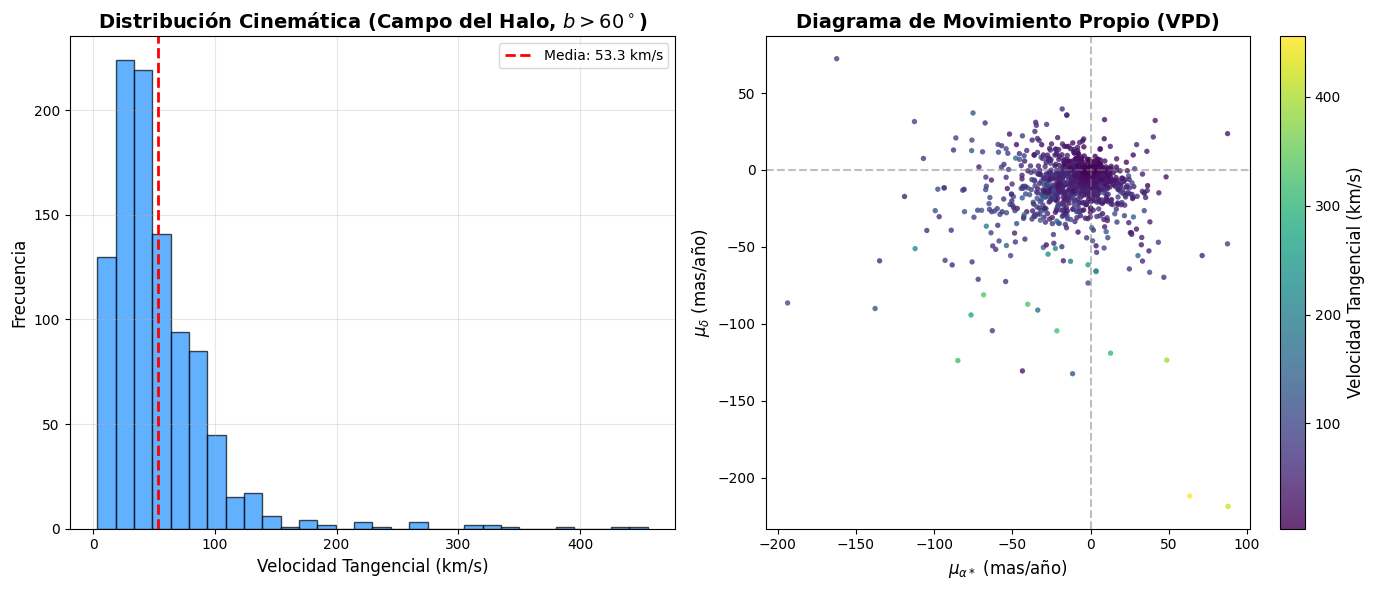

In [5]:
from astroquery.gaia import Gaia
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Consulta ADQL limpia para ejecución síncrona inmediata
query = """
SELECT TOP 1000 ra, dec, parallax, parallax_error, pmra, pmdec, pmra_error, pmdec_error, ruwe, phot_g_mean_mag, bp_rp
FROM gaiadr3.gaia_source
WHERE parallax > 1.0
  AND parallax_over_error > 10
  AND ruwe < 1.2
  AND b > 60
"""

print("Descargando datos astrométricos de Gaia DR3 (Modo síncrono en tiempo real)...")
# Ejecución síncrona: el script esperará la respuesta inmediata del servidor
job = Gaia.launch_job(query)
df_halo = job.get_results().to_pandas()

# Limpieza de nulos preventiva
df_halo = df_halo.dropna(subset=['pmra', 'pmdec', 'parallax', 'phot_g_mean_mag', 'bp_rp'])

# Cálculo de Velocidad Tangencial Clásica
mu = np.sqrt(df_halo['pmra']**2 + df_halo['pmdec']**2)
df_halo['v_tangencial_km_s'] = 4.74 * (mu / df_halo['parallax'])

print(f"Estrellas extraídas con RUWE < 1.2: {len(df_halo)}")
print(f"Velocidad Tangencial Promedio en el campo: {df_halo['v_tangencial_km_s'].mean():.1f} km/s")

# Visualización Gráfica Cinemática
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Histograma de Velocidades Tangenciales
ax1.hist(df_halo['v_tangencial_km_s'], bins=30, color='dodgerblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Velocidad Tangencial (km/s)', fontsize=12)
ax1.set_ylabel('Frecuencia', fontsize=12)
ax1.set_title('Distribución Cinemática (Campo del Halo, $b > 60^\circ$)', fontsize=14, fontweight='bold')
ax1.axvline(df_halo['v_tangencial_km_s'].mean(), color='red', linestyle='dashed', linewidth=2,
            label=f'Media: {df_halo["v_tangencial_km_s"].mean():.1f} km/s')
ax1.legend()
ax1.grid(alpha=0.3)

# Panel 2: Diagrama de Movimientos Propios (VPD)
scatter = ax2.scatter(df_halo['pmra'], df_halo['pmdec'], s=15, c=df_halo['v_tangencial_km_s'],
                      cmap='viridis', alpha=0.8, edgecolor='none')
ax2.set_xlabel('$\mu_{\\alpha*}$ (mas/año)', fontsize=12)
ax2.set_ylabel('$\mu_{\delta}$ (mas/año)', fontsize=12)
ax2.set_title('Diagrama de Movimiento Propio (VPD)', fontsize=14, fontweight='bold')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(0, color='gray', linestyle='--', alpha=0.5)

cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Velocidad Tangencial (km/s)', fontsize=12)

plt.tight_layout()
plt.show()

## 3. Detección de Corrientes Estelares y Colas de Marea

Los cúmulos globulares y galaxias enanas que orbitan la Vía Láctea están sometidos al gradiente gravitacional (fuerza de marea) de la Galaxia. Cuando las estrellas cruzan la superficie equipotencial de Roche, escapan del cúmulo formando "colas de marea": una adelantada (leading) y otra atrasada (trailing).

### El Radio de Jacobi3.1

El límite de influencia gravitacional de un cúmulo estelar de masa $m$ que orbita una galaxia anfitriona de masa $M_G$ a una distancia $R_G$ se define como el Radio de Jacobi ($r_J$).

Igualando la aceleración de marea ejercida por la Galaxia a la gravedad de autoligadura del cúmulo en un marco de referencia rotatorio:

$$G \frac{m}{r_J^2} = \Omega^2 r_J - \left. \frac{d^2 \Phi_G}{dR^2} \right|_{R_G} r_J$$

Para una galaxia masiva puntual, $\Omega^2 = GM_G/R_G^3$ y la derivada del potencial arroja un factor $2GM_G/R_G^3$. Resolviendo para $r_J$, obtenemos la aproximación clásica:

$$r_J \approx R_G \left( \frac{m}{3 M_G} \right)^{1/3}$$

Las estrellas que por interacciones dinámicas cruzan $r > r_J$ son extraídas cinemáticamente. Las estrellas expulsadas hacia el interior orbital ($< R_G$) ganan velocidad angular y forman la cola *adelantada*; las expulsadas hacia el exterior ($> R_G$) pierden velocidad angular y forman la cola *atrasada*.

### 3.2 Dinámica de las Colas Leading y Trailing

La disrupción cinemática crea invariablemente una morfología en forma de "S", dividida en dos colas debido a la conservación del momento angular y la Tercera Ley de Kepler:

- **Cola Adelantada (Leading Tail)**: Las estrellas que escapan a través del punto de Lagrange interior ($L_1$, más cercano al centro galáctico) caen a un radio orbital levemente menor que el del cúmulo. Según las leyes de Kepler ($P^2 ∝ a^3$), una órbita menor implica un período más corto y mayor velocidad angular. Estas estrellas orbitan más rápido y se "adelantan" al cúmulo.

- **Cola Atrasada (Trailing Tail)**: Las estrellas que escapan por el punto de Lagrange exterior ($L_2$) pasan a una órbita con mayor semieje mayor. Tienen menor velocidad angular, tardan más en completar una revolución y, sistemáticamente, se "atrasan" respecto al movimiento sistémico del progenitor.

Esta cinemática es la que simulamos en el laboratorio N-Body, evidenciando cómo el gradiente de potencial galáctico ordena geométricamente los escombros estelares.

### Simulación Computacional: Destrucción por Mareas (N-Body 2D)


Radio de Jacobi del sistema: 2.99


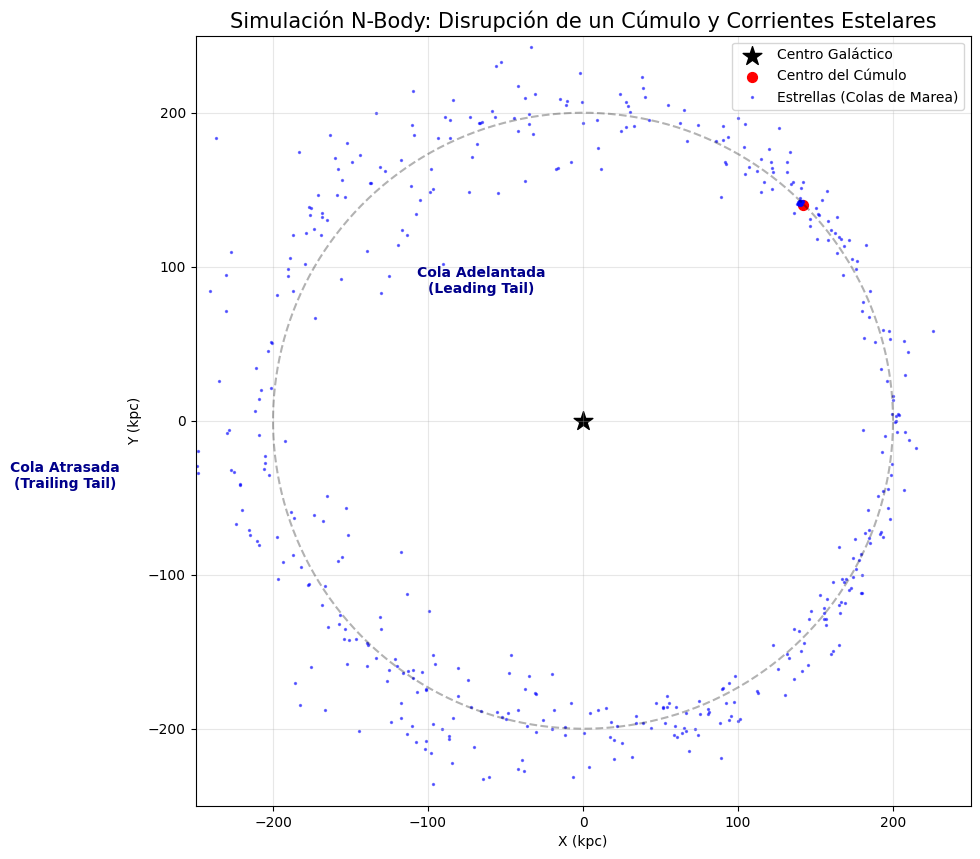

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros físicos (Unidades arbitrarias: G=1)
G = 1.0
M_gal = 100000.0  # Masa de la Galaxia
M_clu = 1.0       # Masa del Cúmulo
R_orbit = 200.0   # Radio de la órbita del cúmulo

# Velocidad circular del cúmulo
V_clu = np.sqrt(G * M_gal / R_orbit)

# Inicialización de 500 partículas (Estrellas del cúmulo)
N_particles = 500
r_J = R_orbit * (M_clu / (3 * M_gal))**(1/3) # Radio de Jacobi Teórico
print(f"Radio de Jacobi del sistema: {r_J:.2f}")

# Distribución gaussiana de posiciones dentro del cúmulo
np.random.seed(101)
dx = np.random.normal(0, r_J*0.5, N_particles)
dy = np.random.normal(0, r_J*0.5, N_particles)
x = R_orbit + dx
y = 0.0 + dy

# Velocidades iniciales (Velocidad del cúmulo + dispersión aleatoria virializada)
v_dispersion = np.sqrt(G * M_clu / r_J) * 1.5
vx = 0.0 + np.random.normal(0, v_dispersion, N_particles)
vy = V_clu + np.random.normal(0, v_dispersion, N_particles)

# Parámetros de integración (Método de Euler Semi-Implícito / Leapfrog)
dt = 0.1
t_max = 850.0  # Suficiente para dar ~1 órbita y media
pasos = int(t_max / dt)

# Trayectoria del centro del cúmulo para referencia
x_c, y_c = R_orbit, 0.0
vx_c, vy_c = 0.0, V_clu

for step in range(pasos):
    # Fuerza sobre el centro del cúmulo (Solo Galaxia)
    r_c = np.sqrt(x_c**2 + y_c**2)
    ax_c = -G * M_gal * x_c / r_c**3
    ay_c = -G * M_gal * y_c / r_c**3

    vx_c += ax_c * dt
    vy_c += ay_c * dt
    x_c += vx_c * dt
    y_c += vy_c * dt

    # Fuerzas sobre las partículas (Galaxia + Cúmulo)
    r_gal = np.sqrt(x**2 + y**2)
    r_rel = np.sqrt((x - x_c)**2 + (y - y_c)**2)

    # Prevención de divergencia en r=0 (Softening)
    epsilon = 0.5

    ax = -G * M_gal * x / r_gal**3 - G * M_clu * (x - x_c) / (r_rel**3 + epsilon**3)
    ay = -G * M_gal * y / r_gal**3 - G * M_clu * (y - y_c) / (r_rel**3 + epsilon**3)

    vx += ax * dt
    vy += ay * dt
    x += vx * dt
    y += vy * dt

# Gráfica del resultado final
plt.figure(figsize=(10, 10))
plt.scatter(0, 0, color='black', s=200, marker='*', label='Centro Galáctico')
plt.scatter(x_c, y_c, color='red', s=50, label='Centro del Cúmulo')
plt.scatter(x, y, color='blue', s=2, alpha=0.5, label='Estrellas (Colas de Marea)')

# Dibujar la órbita teórica del cúmulo
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(R_orbit * np.cos(theta), R_orbit * np.sin(theta), 'k--', alpha=0.3)

# Identificación física de las colas en la gráfica
r_final = np.sqrt(x**2 + y**2)
plt.text(x[np.argmin(r_final)], y[np.argmin(r_final)]-15, "Cola Adelantada\n(Leading Tail)", color='darkblue', fontweight='bold', ha='center')
plt.text(x[np.argmax(r_final)], y[np.argmax(r_final)]+15, "Cola Atrasada\n(Trailing Tail)", color='darkblue', fontweight='bold', ha='center')

plt.xlim(-250, 250)
plt.ylim(-250, 250)
plt.title("Simulación N-Body: Disrupción de un Cúmulo y Corrientes Estelares", fontsize=15)
plt.xlabel("X (kpc)")
plt.ylabel("Y (kpc)")
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

# Ejercicios Prácticos

## 4. Ejercicios Prácticos

1. **Derivación de Homología:** Demuestre analíticamente paso a paso cómo la relación $t_{\text{MS}} \propto M/L$ se convierte en $\frac{\Delta t}{t} \approx -1.3 \Delta Y$. Asuma que la masa en el Turn-Off obedece $L \propto M^{4.5}$ para estrellas de baja masa y analice las variaciones fraccionales.

2. **Minería de Datos (Mapas Cromosómicos):** Utilizando el archivo del Hubble Space Telescope (`astroquery.mast`), descargue los datos de fotometría en filtros F275W, F336W, F438W y F814W para el cúmulo globular NGC 2808. Calcule el pseudo-color $C_{F275W, F336W, F438W}$ y genere su mapa cromosómico[cite: 4]. Identifique empíricamente cuántas poblaciones distintas (clústers de puntos) puede separar.

3. **Radio de Jacobi de Palomar 5:** El cúmulo globular Palomar 5 tiene una masa residual de $m \approx 4500 M_\odot$ y orbita a una distancia galactocéntrica $R_G \approx 18.6$ kpc. Asumiendo que la masa de la Vía Láctea encerrada en ese radio es $M_G \approx 1.5 \times 10^{11} M_\odot$, calcule su Radio de Jacobi actual en parsecs[cite: 4]. Compare este límite teórico con la dispersión observada de su corriente estelar.

## 5. Bibliografía de Referencia[cite: 4]

* **Bastian, N., & Lardo, C. (2018).** *Multiple Stellar Populations in Globular Clusters.* Annual Review of Astronomy and Astrophysics, 56, 83-136. (Revisión fundamental del paradigma roto).
* **Milone, A. P., et al. (2017).** *The Hubble Space Telescope UV Legacy Survey of Galactic Globular Clusters - IX. The Chromosome Map of 57 Globular Clusters.* Monthly Notices of the Royal Astronomical Society, 464(3), 3636-3656.
* **Kippenhahn, R., Weigert, A., & Weiss, A. (2012).** *Stellar Structure and Evolution.* Springer. (Para derivaciones rigurosas de homología y opacidad de Kramers).
* **Binney, J., & Tremaine, S. (2008).** *Galactic Dynamics* (2nd ed.). Princeton University Press. (Capítulo sobre fuerzas de marea, Radio de Jacobi y formación de corrientes).
* **Gaia Collaboration et al. (2022).** *Gaia Data Release 3: Summary of the content and survey properties.* Astronomy & Astrophysics. (Referencia para consultas de la base de datos astrométrica).

In [7]:
## Escriba aquí su solución